### Lightweight IDS Using Machine Learning for IoT Devices
## Notebook 01: Data Preprocessing

**Author:** Mimi Nguyet Mi Taylor  
**Programme:** MSc Computer Science, Birkbeck, University of London  
**Supervisor:** Professor Paul Yoo

---

### About this notebook 
This notebook implements the preprocessing pipeline described in the project methodology:
1. Load the CICIoT2023 dataset (all 63 CSV files).
2. Map the 33 attack types to 7 high-level attack categories, plus Benign.
3. Take a stratified sample of 1,000,000 records.
4. Save the sample for use in subsequent preprocessing steps

Data cleaning, feature selection, train/test split and SMOTE-ENN are handled in Notebook 02.

### Dataset
**CICIoT2023** (Neto et al., 2023)  
Source: https://www.unb.ca/cic/datasets/iotdataset-2023.html  
- 63 merged CSV files
- ~45 million network flow records
- 39 features + 1 label column
- 33 attack types across 7 categories, plus Benign traffic (34 classes total)

---
## Step 1: Import Libraries

In [1]:
# Standard libraries for data handling and machine learning
import pandas as pd           # data loading and manipulation
import os                     # file path handling
from sklearn.model_selection import train_test_split  # stratified sampling
import matplotlib.pyplot as plt  # plotting the class distribution

print("Libraries imported successfully")

Libraries imported successfully


---
## Step 2: Define the Attack Category Mapping

CICIoT2023 contains 33 distinct attack types, plus Benign traffic, a total of 34 classes.
This project evaluates classifiers across the 7 high-level attack categories defined by
Neto et al. (2023): DDoS, DoS, Mirai, Reconnaissance, Web-based, Brute Force, and Spoofing.

Each specific attack label is mapped to its parent category here.

In [2]:
# Mapping from specific attack labels to the 7 high-level categories
# defined by Neto et al. (2023) plus Benign traffic.
# This mapping was verified against the CICIoT2023 dataset documentation.

category_map = {
    # DDoS attacks: volumetric attacks overwhelming network resources
    'DDOS-ICMP_FLOOD': 'DDoS',
    'DDOS-UDP_FLOOD': 'DDoS',
    'DDOS-TCP_FLOOD': 'DDoS',
    'DDOS-PSHACK_FLOOD': 'DDoS',
    'DDOS-RSTFINFLOOD': 'DDoS',
    'DDOS-SYN_FLOOD': 'DDoS',
    'DDOS-SYNONYMOUSIP_FLOOD': 'DDoS',
    'DDOS-HTTP_FLOOD': 'DDoS',
    'DDOS-SLOWLORIS': 'DDoS',
    'DDOS-ICMP_FRAGMENTATION': 'DDoS',
    'DDOS-ACK_FRAGMENTATION': 'DDoS',
    'DDOS-UDP_FRAGMENTATION': 'DDoS',

    # DoS attacks: single-source denial of service
    'DOS-UDP_FLOOD': 'DoS',
    'DOS-TCP_FLOOD': 'DoS',
    'DOS-SYN_FLOOD': 'DoS',
    'DOS-HTTP_FLOOD': 'DoS',

    # Mirai botnet attacks
    'MIRAI-GREETH_FLOOD': 'Mirai',
    'MIRAI-UDPPLAIN': 'Mirai',
    'MIRAI-GREIP_FLOOD': 'Mirai',

    # Reconnaissance: network scanning and discovery
    'RECON-HOSTDISCOVERY': 'Reconnaissance',
    'RECON-OSSCAN': 'Reconnaissance',
    'RECON-PORTSCAN': 'Reconnaissance',
    'RECON-PINGSWEEP': 'Reconnaissance',
    'VULNERABILITYSCAN': 'Reconnaissance',

    # Spoofing attacks: identity/address spoofing
    'MITM-ARPSPOOFING': 'Spoofing',
    'DNS_SPOOFING': 'Spoofing',

    # Web-based attacks: application layer attacks
    'SQLINJECTION': 'Web-based',
    'XSS': 'Web-based',
    'COMMANDINJECTION': 'Web-based',
    'BACKDOOR_MALWARE': 'Web-based',
    'BROWSERHIJACKING': 'Web-based',
    'UPLOADING_ATTACK': 'Web-based',

    # Brute Force: password/credential attacks
    'DICTIONARYBRUTEFORCE': 'Brute Force',

    # Benign: normal traffic
    'BENIGN': 'Benign'
}

print(f"Category map defined: {len(category_map) - 1} attack labels mapped to 7 attack categories, plus Benign ({len(category_map)} classes total)")
print("\nCategories:")
for cat in sorted(set(category_map.values())):
    count = sum(1 for v in category_map.values() if v == cat)
    print(f"  {cat}: {count} attack type(s)")

Category map defined: 33 attack labels mapped to 7 attack categories, plus Benign (34 classes total)

Categories:
  Benign: 1 attack type(s)
  Brute Force: 1 attack type(s)
  DDoS: 12 attack type(s)
  DoS: 4 attack type(s)
  Mirai: 3 attack type(s)
  Reconnaissance: 5 attack type(s)
  Spoofing: 2 attack type(s)
  Web-based: 6 attack type(s)


---
## Step 3: Load All 63 CSV Files

The CICIoT2023 dataset is split across 63 merged CSV files stored in the MERGED_CSV folder.
Each file is loaded, the category mapping is applied, and all files are concatenated
into a single dataframe.

**Note:** This step loads ~45 million rows and may take several minutes.

In [3]:
# Path to the folder containing all 63 CSV files
folder = 'MERGED_CSV'

# Get a sorted list of all CSV files in the folder
files = sorted([f for f in os.listdir(folder) if f.endswith('.csv')])
print(f"Found {len(files)} CSV files in {folder}/")

Found 63 CSV files in MERGED_CSV/


In [4]:
# Load all 63 files and apply the category mapping to each one.
# Files are loaded one at a time and added to a list to avoid
# memory issues from holding multiple large dataframes simultaneously.
# Progress is printed for each file so we can track loading.
# Note: raw data has 39 features + Label (40 columns). 
# Category is added here, bringing the total to 41 columns.

dfs = []
for f in files:
    temp = pd.read_csv(os.path.join(folder, f))
    temp['Category'] = temp['Label'].map(category_map)
    dfs.append(temp)
    print(f"Loaded {f} — {len(temp):,} rows")

# Concatenate all files into a single dataframe
# ignore_index=True resets the row index so it runs 0, 1, 2... continuously
df_all = pd.concat(dfs, ignore_index=True)

print(f"\n--- Full dataset loaded ---")
print(f"Total rows:    {df_all.shape[0]:,}")
print(f"Total columns: {df_all.shape[1]}")
print(f"\nCategory counts (full dataset):")
print(df_all['Category'].value_counts())
print(f"\nUnmapped labels (should be very small): {df_all['Category'].isna().sum()}")

Loaded Merged01.csv — 712,311 rows
Loaded Merged02.csv — 748,585 rows
Loaded Merged03.csv — 697,289 rows
Loaded Merged04.csv — 676,620 rows
Loaded Merged05.csv — 744,804 rows
Loaded Merged06.csv — 718,229 rows
Loaded Merged07.csv — 702,212 rows
Loaded Merged08.csv — 712,220 rows
Loaded Merged09.csv — 678,882 rows
Loaded Merged10.csv — 916,190 rows
Loaded Merged11.csv — 909,761 rows
Loaded Merged12.csv — 896,941 rows
Loaded Merged13.csv — 709,937 rows
Loaded Merged14.csv — 902,920 rows
Loaded Merged15.csv — 718,483 rows
Loaded Merged16.csv — 765,369 rows
Loaded Merged17.csv — 731,532 rows
Loaded Merged18.csv — 714,063 rows
Loaded Merged19.csv — 701,978 rows
Loaded Merged20.csv — 719,927 rows
Loaded Merged21.csv — 692,566 rows
Loaded Merged22.csv — 739,382 rows
Loaded Merged23.csv — 688,470 rows
Loaded Merged24.csv — 743,201 rows
Loaded Merged25.csv — 700,455 rows
Loaded Merged26.csv — 878,940 rows
Loaded Merged27.csv — 720,736 rows
Loaded Merged28.csv — 706,379 rows
Loaded Merged29.csv 

---
## Step 4: Remove Unmapped Records

A small number of records may have labels not present in our category map.
These are removed before sampling to ensure a clean dataset.

In [5]:
# Remove rows where Category is NaN (i.e. the label was not in category_map)
# dropna with subset=['Category'] only removes rows where Category is missing,
# not rows where other columns are missing (that is handled in Notebook 02)

rows_before = len(df_all)
df_clean = df_all.dropna(subset=['Category'])
rows_removed = rows_before - len(df_clean)

print(f"Rows before: {rows_before:,}")
print(f"Rows removed (unmapped labels): {rows_removed}")
print(f"Rows after:  {len(df_clean):,}")

Rows before: 45,019,243
Rows removed (unmapped labels): 9
Rows after:  45,019,234


---
## Step 5: Stratified Sampling

A stratified random sample of 1,000,000 records is taken because it is not feasible to process the full dataset (~45 million records) due to the limitations of 
consumer hardware.

**Rationale for using stratified sampling**  
Stratified sampling preserves the class proportions from the full dataset in the sample.
This ensures all 7 attack categories plus Benign (including minority classes like Brute Force and Web-based) are represented proportionally, rather than being lost in a random sample.

**Rational for using 1,000,000 records**  
- Computationally feasible on available hardware (MacBook Air M3, 16GB RAM)
- Provides sufficient minority class representation for model training
- Consistent with the literature: Al-Ashmali et al. (2025) used 238,687 records;
  our sample is approximately 4x larger, providing more robust evaluation

**Using random_state=42**  
A fixed random seed ensures the same sample is produced every time this notebook
is run, making results fully reproducible.

In [6]:
# Take a stratified random sample of 1,000,000 records.
# train_test_split is used here purely for its stratify functionality,
# the actual train/test split for model evaluation is done in Notebook 02.
# The second return value (_) is the remainder of the dataset which we discard.

df_sample, _ = train_test_split(
    df_clean,
    train_size=1_000_000,          # sample size
    stratify=df_clean['Category'], # preserve category proportions
    random_state=42                # fixed seed for reproducibility
)

print(f"--- Stratified sample created ---")
print(f"Sample size: {len(df_sample):,}")
print(f"\nCategory counts in sample:")
print(df_sample['Category'].value_counts())
print(f"\nClass proportions (should match full dataset):")
print((df_sample['Category'].value_counts() / len(df_sample) * 100).round(2).astype(str) + '%')

--- Stratified sample created ---
Sample size: 1,000,000

Category counts in sample:
Category
DDoS              722718
DoS               172072
Mirai              56014
Benign             23354
Reconnaissance     14685
Spoofing           10350
Web-based            529
Brute Force          278
Name: count, dtype: int64

Class proportions (should match full dataset):
Category
DDoS              72.27%
DoS               17.21%
Mirai               5.6%
Benign             2.34%
Reconnaissance     1.47%
Spoofing           1.03%
Web-based          0.05%
Brute Force        0.03%
Name: count, dtype: str


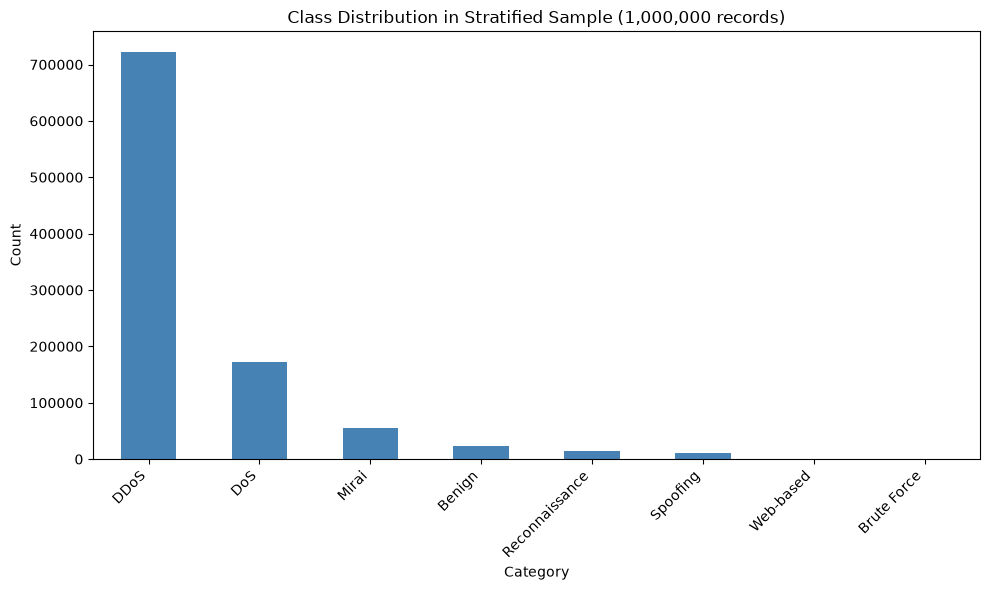

Plot saved.


In [7]:
# Plot class distribution in the stratified sample.
# This figure is included in the report (Chapter 2) to show the severe class imbalance 
# adressed with SMOTE-ENN in Notebook 02.

plt.figure(figsize=(10, 6))
class_counts = df_sample['Category'].value_counts()
class_counts.plot(kind='bar', color='steelblue')
plt.title('Class Distribution in Stratified Sample (1,000,000 records)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.expanduser("~/IDS_PROJECT_REPORT/class_distribution.png"), dpi=150)
plt.show()
print("Plot saved.")

---
## Step 6: Save the Sample

The stratified sample is saved as a CSV file for use in Notebook 02 (data cleaning,
feature selection, train/test split and SMOTE-ENN).

Saving at this point means we never need to reload all 63 original files again.

In [8]:
# Save the stratified sample to CSV
# index=False prevents pandas writing the row numbers as a column

output_file = 'stratified_sample_1m.csv'
df_sample.to_csv(output_file, index=False)

# Verify the file saved correctly by checking its size
file_size_mb = os.path.getsize(output_file) / (1024 * 1024)
print(f"Saved: {output_file}")
print(f"File size: {file_size_mb:.1f} MB")

Saved: stratified_sample_1m.csv
File size: 218.0 MB


---
## Lightweight checks

These are some simple checks that confirm the pipeline behaved as expected.
    They are lightweight tests using Python's `assert` statements, not fully software development unit tests.
    The purpose of this is to catch silent errors, preventing bad data pass through to later steps and notebooks.  


In [9]:
# Lightweight checks: confirm the category mapping and sampling behaved as expected.

assert len(category_map) == 34, "Expected 34 entries in category_map (33 attacks + Benign)"
assert set(category_map.values()) == {
    'DDoS', 'DoS', 'Mirai', 'Reconnaissance', 'Spoofing', 'Web-based', 'Brute Force', 'Benign'
}, "Category map produced unexpected category names"
assert df_all.shape[1] == 41, f"Expected 41 columns after loading, got {df_all.shape[1]}"
assert df_sample.shape[0] == 1_000_000, f"Expected 1,000,000 sampled rows, got {df_sample.shape[0]}"

print("All checks passed.")

All checks passed.


---
## Summary

In [10]:
rows_removed_unmapped = len(df_all) - len(df_clean)

print(f"{'Step':<10} {'Description':<50} {'Result'}")
print("-" * 100)
print(f"{'Load':<10} {'All 63 CSV files loaded':<50} {df_all.shape[0]:,} rows, 39 features")
print(f"{'Map':<10} {'33 attack labels to 7 categories + Benign (34 classes total)':<50} {rows_removed_unmapped} unmapped records removed")
print(f"{'Sample':<10} {'Stratified sample taken':<50} {df_sample.shape[0]:,} rows, proportions preserved")
print(f"{'Save':<10} {'Sample saved to CSV':<50} {output_file} (~{file_size_mb:.0f} MB)")

Step       Description                                        Result
----------------------------------------------------------------------------------------------------
Load       All 63 CSV files loaded                            45,019,243 rows, 39 features
Map        33 attack labels to 7 categories + Benign (34 classes total) 9 unmapped records removed
Sample     Stratified sample taken                            1,000,000 rows, proportions preserved
Save       Sample saved to CSV                                stratified_sample_1m.csv (~218 MB)
